# PINO pipeline for 2D Darcy problem

This extends the vanilla FNO with a physics-informed (PINO) training loop.

**What changed vs. the FNO notebook:**
- `Trainer` is replaced with a manual training loop that adds a PDE residual loss term.
- A `darcy_pde_residual()` function computes `‖−∇·(a∇u) − f‖²` using Fourier differentiation.
- `lambda_pde` weights the PDE loss relative to the H1 data loss.

In [62]:
# Imports
import numpy as np
import sys
import os

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import DarcyDataset
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt

In [63]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1000
data_n_tests = [100, 50]
data_train_resolution = 64  # options: 16, 32, 64, 128, 421
data_test_resolutions = [64, 128]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(12, 12)
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=64
FNO_n_layers = 4
FNO_factorization="tucker"
FNO_nonlinearity= F.gelu

# === Training ===
TRAIN_epochs = 200

# === PINO-specific ===
# Weight of PDE loss relative to data (H1) loss.
lambda_pde = 1e-4

# Darcy forcing: f = 1 everywhere (as per the standard benchmark)
DARCY_FORCING = 1.0

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

N = 64
M = 256
L = 1.0


def sample_GP_operator(N=64, M=256):
    h_fine = 1 / M
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    A_eigs = KX**2 + KY**2 + 9.0
    Cov_eigs = 1.0 / (A_eigs**2)
    z = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(Cov_eigs) * z
    u_fine = np.fft.ifft2(u_hat).real * M**2
    step = M // N
    return u_fine[::step, ::step]


def sample_GP_operator_masked(u_current, bandwidth=0.1, smooth_sigma=2.0):
    xi = sample_GP_operator()
    mask = (np.abs(u_current) < bandwidth).astype(float)
    mask = gaussian_filter(mask, sigma=smooth_sigma)
    if mask.max() > 1e-8:
        mask = mask / (mask.std() + 1e-8)
    return xi * mask


def sample_GP_operator_mixed(u_current, bandwidth=0.1,
                               smooth_sigma=2.0, interface_weight=0.8):
    if np.random.rand() < interface_weight:
        return sample_GP_operator_masked(u_current, bandwidth, smooth_sigma)
    else:
        return sample_GP_operator()


In [65]:
def T_push(x, tau=-1, boundary=0):
    """Smooth (or hard) threshold to map GP samples to binary permeability fields."""
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5

In [66]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [67]:
# Import Data
dataset = DarcyDataset(
    root_dir="./darcy_data",
    n_train=data_n_train,
    n_tests=data_n_tests,
    train_resolution=data_train_resolution,
    batch_size=data_batch_size,
    test_resolutions=data_test_resolutions,
    test_batch_sizes=data_test_batch_sizes,
)

# Renormalise to 3-12 range (run once only)
for test_set in dataset.test_dbs.values():
    test_set.x = T_push(test_set.x, tau=-1, boundary=0.5)
dataset._train_db.x = T_push(dataset._train_db.x, tau=-1, boundary=0.5)

train_loader = DataLoader(
    dataset.train_db,
    batch_size=data_batch_size,
    num_workers=1,
    pin_memory=True,
    persistent_workers=False,
)

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor

Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 


In [68]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
)
model = model.to(device)

n_params = count_model_params(model)
print(f"\nModel has {n_params} parameters.")
sys.stdout.flush()

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)


Model has 2870473 parameters.


In [69]:
import numpy as np
def make_mollifier(N, device):
    xs = torch.linspace(0, 1, N, device=device)
    mx, my = torch.meshgrid(xs, xs, indexing='ij')
    return (torch.sin(np.pi*mx) * torch.sin(np.pi*my))[None, None]  # (1,1,N,N)

mollifiers = {res: make_mollifier(res, device) for res in set(data_test_resolutions + [data_train_resolution])}

def predict(a):                       # use this instead of model(a) everywhere
    return model(a) * mollifiers[a.shape[-1]]

In [ ]:
# ===========================================================================
# PINO: Darcy PDE residual via Fourier differentiation
# ===========================================================================
#
# Darcy's law (strong form):
#   -∇·(a(x) ∇u(x)) = f,   x ∈ (0,1)²
#   u = 0  on  ∂(0,1)²
#
# Expanding the divergence: -(∇a · ∇u + a Δu) = f
#
# We compute ∂_x u, ∂_y u, Δu = ∂_xx u + ∂_yy u  via the Fourier method:
#   û(k) → ik û(k)   for first derivative
#   û(k) → -k² û(k)  for second derivative
#
# The domain is [0,1]² with a Dirichlet zero boundary, so we use the
# Fourier sine transform (FST) which is exact for functions that vanish
# on the boundary. torch.fft.dstn / idst are available in PyTorch >= 2.1.
# For older versions we fall back to zero-padded FFT (Fourier continuation),
# which is less accurate near boundaries but still useful as a soft constraint.
# ===========================================================================

# def _fourier_diff_periodic(u: torch.Tensor, dx: float) -> tuple:
#     B, C, Nx, Ny = u.shape
    
#     # Reflect-pad to avoid Gibbs errors at non-periodic boundaries
#     u_padded = F.pad(u, (0, Ny - 1, 0, Nx - 1), mode="reflect")  # (B, C, 2Nx-1, 2Ny-1)
#     _, _, Nx_p, Ny_p = u_padded.shape
    
#     u_hat = torch.fft.rfft2(u_padded)

#     kx = torch.fft.fftfreq(Nx_p, d=dx).to(u.device)
#     ky = torch.fft.rfftfreq(Ny_p, d=dx).to(u.device)
#     KX = kx[:, None] * 2 * torch.pi
#     KY = ky[None, :] * 2 * torch.pi

#     du_dx_hat =  1j * KX * u_hat
#     du_dy_hat =  1j * KY * u_hat
#     lap_u_hat = -(KX**2 + KY**2) * u_hat

#     # Crop back to original domain after inverse transform
#     du_dx = torch.fft.irfft2(du_dx_hat, s=(Nx_p, Ny_p))[:, :, :Nx, :Ny]
#     du_dy = torch.fft.irfft2(du_dy_hat, s=(Nx_p, Ny_p))[:, :, :Nx, :Ny]
#     lap_u = torch.fft.irfft2(lap_u_hat, s=(Nx_p, Ny_p))[:, :, :Nx, :Ny]

#     return du_dx, du_dy, lap_u



# # Strong formulation of PDE
# def darcy_pde_residual(
#     a: torch.Tensor,
#     u: torch.Tensor,
#     forcing: float = DARCY_FORCING,
# ) -> torch.Tensor:
#     """
#     Computes the mean-squared Darcy residual:
#         MSE[ −(∇a · ∇u + a Δu) − f ]

#     Args:
#         a: permeability field,  shape (B, 1, Nx, Ny)
#         u: predicted solution,  shape (B, 1, Nx, Ny)
#         forcing: scalar f (1.0 for the standard Darcy benchmark)

#     Returns:
#         Scalar tensor (the PDE loss for this batch).

#     Note on boundary accuracy:
#         We use periodic-FFT differentiation with zero-padding (Fourier
#         continuation) to approximate derivatives on the non-periodic
#         domain. This introduces a small Gibbs error near the boundary,
#         but is perfectly adequate as a soft physics constraint. The
#         boundary condition u=0 is implicitly encouraged by the data loss.
#         If you need higher boundary accuracy, switch to FST (uncomment
#         the dstn branch below, requires PyTorch >= 2.1).
#     """
#     B, C, Nx, Ny = u.shape
#     dx = 1.0 / Nx  # grid spacing on [0,1]²

#     # --- derivatives of u ---
#     du_dx, du_dy, lap_u = _fourier_diff_periodic(u, dx)

#     # --- derivatives of a ---
#     da_dx, da_dy, _ = _fourier_diff_periodic(a, dx)

#     # --- Darcy operator: -∇·(a∇u) = -(∂_x a · ∂_x u + ∂_y a · ∂_y u + a Δu) ---
#     residual = -(da_dx * du_dx + da_dy * du_dy + a * lap_u) - forcing

#     scale = (a * lap_u).detach().pow(2).mean().clamp(min=1e-8)
#     return (residual ** 2).mean() / scale


# def darcy_pde_residual(a, u, forcing=DARCY_FORCING):
#     B, C, Nx, Ny = u.shape
#     dx = 1.0 / Nx

#     du_dx, du_dy, _ = _fourier_diff_periodic(u, dx)

#     # Weak form: minimise -½(a∇u·∇u) - (u,f)
#     # At the true solution this equals the negative of the strain energy,
#     # so minimising it drives u toward satisfying -∇·(a∇u) = f
#     grad_u_sq = a * (du_dx**2 + du_dy**2)
#     weak_residual = -0.5 * grad_u_sq.mean() - (u * forcing).mean()

#     # Return magnitude (we minimise the absolute value since the true solution
#     # is a minimum of the energy functional)
#     return weak_residual.abs()

# Using FDM
def darcy_pde_residual(a, u, f=1.0):
    a = a.squeeze(1); u = u.squeeze(1)              # (B,N,N); u must satisfy u=0 on bdry
    dx = 1.0 / (u.shape[-1] - 1)
    # harmonic mean of a at the cell faces (correct for discontinuous a)
    axp = 2*a[:, 1:, :]*a[:, :-1, :] / (a[:, 1:, :] + a[:, :-1, :])   # i+1/2
    ayp = 2*a[:, :, 1:]*a[:, :, :-1] / (a[:, :, 1:] + a[:, :, :-1])   # j+1/2
    Fx = axp * (u[:, 1:, :] - u[:, :-1, :]) / dx
    Fy = ayp * (u[:, :, 1:] - u[:, :, :-1]) / dx
    divx = (Fx[:, 1:, :] - Fx[:, :-1, :]) / dx       # (B,N-2,N)
    divy = (Fy[:, :, 1:] - Fy[:, :, :-1]) / dx       # (B,N,N-2)
    res = -(divx[:, :, 1:-1] + divy[:, 1:-1, :]) - f
    return (res ** 2).mean()

def sample_new_a(batch_size, N=64):
    samples = np.stack([
        T_push(sample_GP_operator(N=N), tau=-1) 
        for _ in range(batch_size)
    ])  # (B, N, N)
    return torch.tensor(samples, dtype=torch.float32).unsqueeze(1)  # (B, 1, N, N)

def total_variance(x):
    # x: (B, 1, Nx, Ny)
    return (torch.mean(torch.abs(x[..., :, :-1] - x[..., :, 1:])) + 
            torch.mean(torch.abs(x[..., :-1, :] - x[..., 1:, :])))

In [ ]:
# ===========================================================================
# PINO Training loop  (replaces trainer.train())
# ===========================================================================

import shutil

CHECKPOINT_DIR = "./checkpoints_pino_darcy"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SAVE_EVERY = 5
EVAL_EVERY = 5

# We bypass data_processor entirely: the dataset applies no normalisation to a
# (it stays in [3, 12]) and the out_normalizer isn't applied consistently across
# train/eval modes. Working directly with physical fields is simpler and correct.

# --- optionally resume from an existing checkpoint ---
start_epoch = 0
latest_ckpt = os.path.join(CHECKPOINT_DIR, "latest.pt")
if os.path.exists(latest_ckpt):
    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])
    ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch = ckpt["epoch"] + 1
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting from scratch.")

train_loss_history = []
pde_loss_history   = []

for epoch in range(start_epoch, TRAIN_epochs):
    model.train()
    epoch_loss     = 0.0
    epoch_pde_loss = 0.0
    n_batches = 0
    
    for batch in train_loader:
        a      = batch["x"].to(device)   # (B, 1, Nx, Ny), permeability in [3, 12]
        u_true = batch["y"].to(device)   # (B, 1, Nx, Ny), pressure solution

        optimizer.zero_grad()

        # --- data loss on labelled pairs ---
        u_pred    = predict(a)
        loss_data = h1loss(u_pred.squeeze(1), u_true.squeeze(1))
        # --- PDE loss on fresh unlabelled samples (no u_true needed) ---
        a_pde    = sample_new_a(batch_size=a.shape[0]).to(device)
        loss_pde = darcy_pde_residual(a_pde, predict(a_pde))

        lambda_pde_eff = lambda_pde * min(1.0, epoch / 20)
        loss = loss_data + lambda_pde_eff * loss_pde
        loss.backward()
        optimizer.step()

        epoch_loss     += loss_data.item()
        epoch_pde_loss += loss_pde.item()
        n_batches += 1
        # print(f"data loss: {loss_data.item():.4e}")
        # print(f"PDE loss:  {loss_pde.item():.4e}")

    scheduler.step()

    avg_data_loss = epoch_loss / n_batches
    avg_pde_loss  = epoch_pde_loss / n_batches
    train_loss_history.append(avg_data_loss)
    pde_loss_history.append(avg_pde_loss)

    print(f"Epoch {epoch+1:03d}/{TRAIN_epochs} | "
          f"H1 data loss: {avg_data_loss:.4e} | "
          f"PDE loss: {avg_pde_loss:.4e}")
    # print(f"data loss: {avg_data_loss:.4e}")
    # print(f"PDE loss:  {avg_pde_loss:.4e}")
    # print(f"ratio:     {avg_pde_loss / avg_data_loss:.2f}")

    # --- evaluation ---
    if (epoch + 1) % EVAL_EVERY == 0:
        model.eval()
        for res, loader in test_loaders.items():
            total_h1, total_l2, nb = 0.0, 0.0, 0
            with torch.no_grad():
                for batch in loader:
                    a_t  = batch["x"].to(device)
                    u_t  = batch["y"].to(device)
                    u_p  = predict(a_t)
                    total_h1 += h1loss(u_p.squeeze(1), u_t.squeeze(1)).item()
                    total_l2 += l2loss(u_p.squeeze(1), u_t.squeeze(1)).item()
                    nb += 1
            print(f"  Test res={res}: H1={total_h1/nb:.4e}  L2={total_l2/nb:.4e}")

    # --- checkpoint ---
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:04d}.pt")
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "lambda_pde": lambda_pde,
        }, ckpt_path)
        shutil.copy2(ckpt_path, latest_ckpt)
        print(f"  Saved checkpoint: {ckpt_path}")

print("Training complete.")

Starting from scratch.
Epoch 001/200 | H1 data loss: 1.7557e+01 | PDE loss: 8.8617e+05
Epoch 002/200 | H1 data loss: 1.2328e+01 | PDE loss: 2.2047e+05
Epoch 003/200 | H1 data loss: 8.3184e+00 | PDE loss: 6.7726e+04
Epoch 004/200 | H1 data loss: 6.7411e+00 | PDE loss: 7.1137e+04
Epoch 005/200 | H1 data loss: 5.5401e+00 | PDE loss: 6.5123e+04
  Test res=64: H1=1.0591e+01  L2=4.2529e+00
  Test res=128: H1=1.3770e+01  L2=5.4682e+00
  Saved checkpoint: ./checkpoints_pino_darcy/epoch_0005.pt
Epoch 006/200 | H1 data loss: 4.9816e+00 | PDE loss: 5.2716e+04
Epoch 007/200 | H1 data loss: 4.5865e+00 | PDE loss: 5.2182e+04
Epoch 008/200 | H1 data loss: 4.3875e+00 | PDE loss: 4.2988e+04
Epoch 009/200 | H1 data loss: 3.9292e+00 | PDE loss: 3.9283e+04
Epoch 010/200 | H1 data loss: 3.8834e+00 | PDE loss: 3.8594e+04
  Test res=64: H1=8.1070e+00  L2=4.0185e+00
  Test res=128: H1=1.1471e+01  L2=4.4750e+00
  Saved checkpoint: ./checkpoints_pino_darcy/epoch_0010.pt
Epoch 011/200 | H1 data loss: 3.6477e+00 

KeyboardInterrupt: 

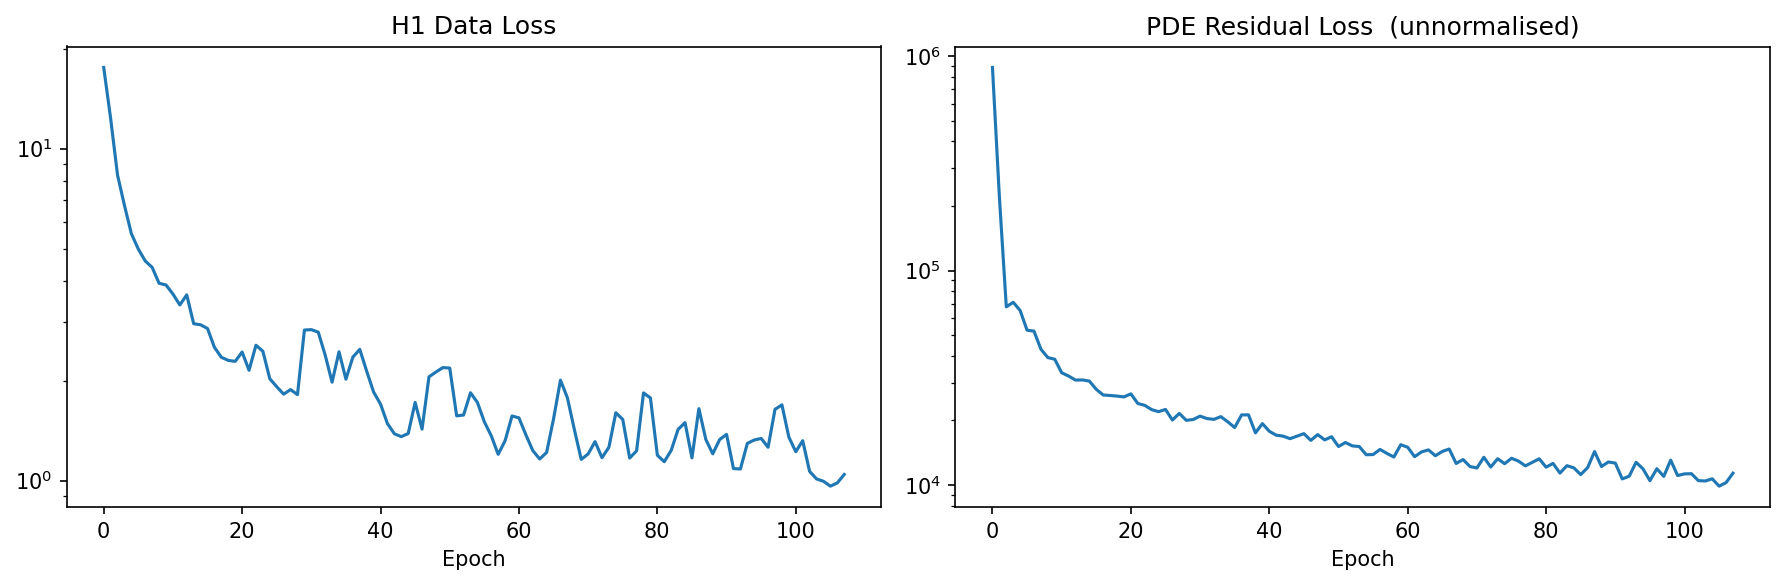

In [35]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.semilogy(train_loss_history)
ax1.set_title("H1 Data Loss")
ax1.set_xlabel("Epoch")

ax2.semilogy(pde_loss_history)
ax2.set_title("PDE Residual Loss  (unnormalised)")
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    sample_a = dataset.train_db[0]["x"].unsqueeze(0).to(device)  # a training example
    sample_u_true = dataset.train_db[0]["y"].unsqueeze(0).to(device)
    sample_u_pred = predict(sample_a)

print("a range:", sample_a.min().item(), sample_a.max().item())
print("u_true range:", sample_u_true.min().item(), sample_u_true.max().item())
print("u_pred range:", sample_u_pred.min().item(), sample_u_pred.max().item())

a range: 3.0 12.0
u_true range: 1.1645013728411868e-05 1.0680791139602661
u_pred range: -0.029744166880846024 1.0882469415664673


In [ ]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
    with torch.no_grad():
        forwards = predict(x)[0, 0]   # (Nx, Ny), already on device
    ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
    return ll


_x_coords = np.linspace(0, 1, data_train_resolution)
_y_coords = np.linspace(0, 1, data_train_resolution)
_X, _Y = np.meshgrid(_x_coords, _y_coords)
_grid_points = np.column_stack([_X.ravel(), _Y.ravel()])
_gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.3))

def sample_GP():
    sample = _gp.sample_y(_grid_points, n_samples=1, random_state=None)
    return sample.reshape(data_train_resolution, data_train_resolution)


_kernel = Matern(length_scale=0.3, nu=1)
K_1d = _kernel(_x_coords.reshape(-1, 1))
K_1d += 1e-6 * np.eye(len(K_1d))
L_1d = np.linalg.cholesky(K_1d)

def sample_GP_kronecker():
    Z = np.random.randn(data_train_resolution, data_train_resolution)
    return L_1d @ Z @ L_1d.T

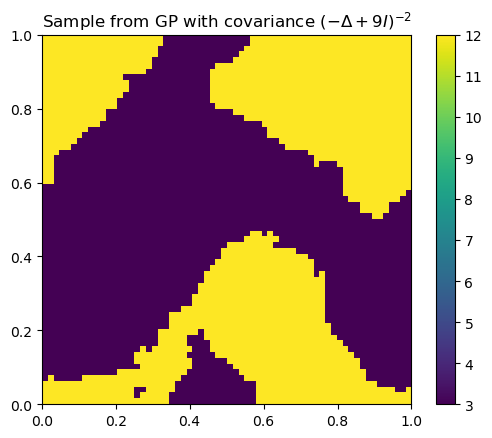

In [38]:
sample = sample_GP_operator()
plt.imshow(T_push(sample_GP_operator(), tau=-1), extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.title(r'Sample from GP with covariance $(-\Delta + 9I)^{-2}$')
plt.show()

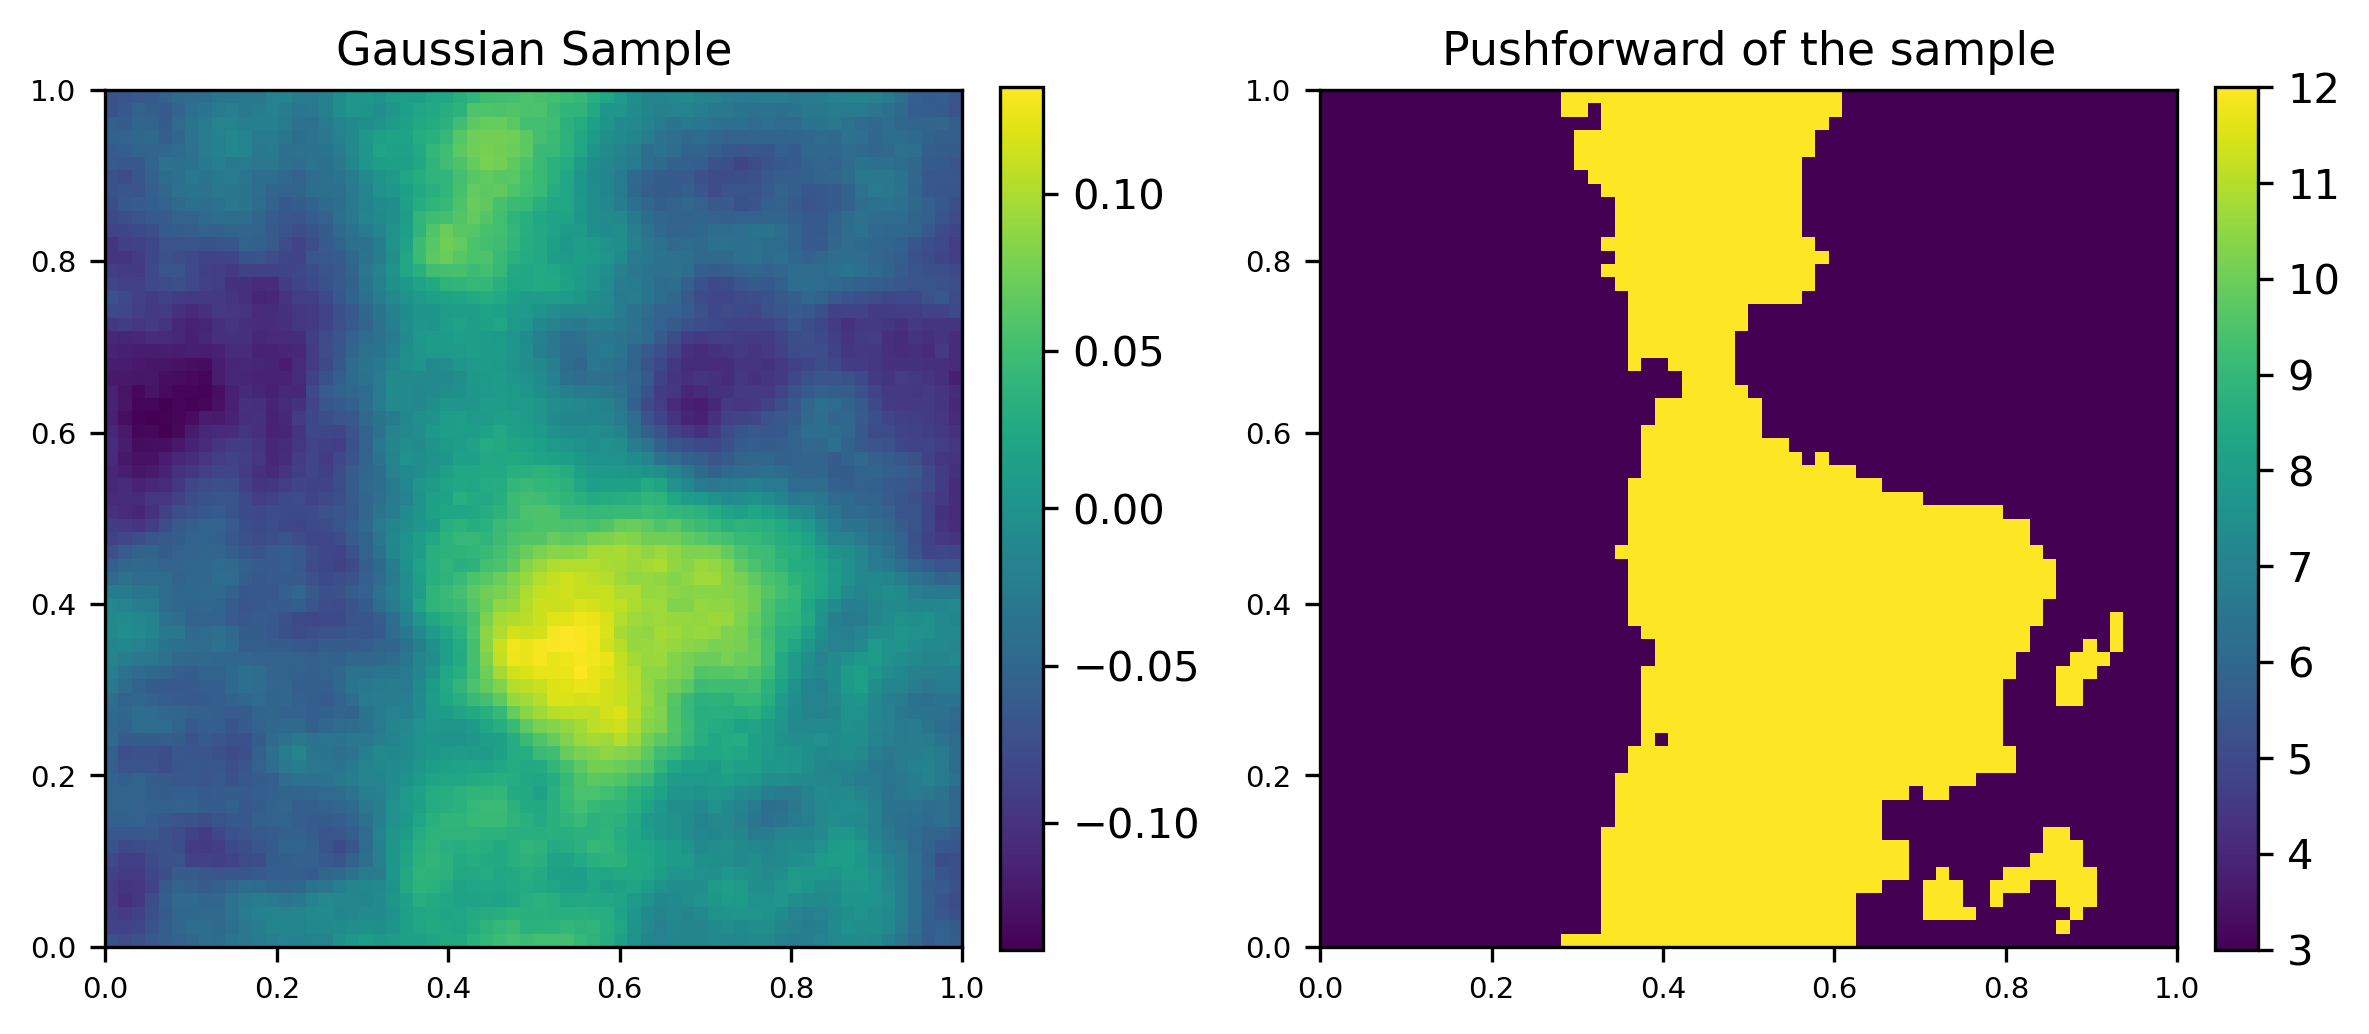

In [39]:
# FINAL REPORT: visualize the sample and its pushforward under T

tf1 = sample_GP_operator(M=256)
tf2 = T_push(tf1, tau=-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", "Pushforward of the sample"]):
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    im = ax.imshow(tf, extent=[0, 1, 0, 1], origin='lower', vmin=tf.min(), vmax=tf.max())
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [40]:
# Get true field from test set
true_field = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)
true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0)

sigma = true_observations.std().item()

accepted = 0
u_0 = sample_GP_operator()
theta_0 = T_push(u_0, tau=-1)
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
theta_evolution = [theta_0]
loss_evolution = []
accepted = []

In [41]:
from collections import deque

# === MCMC HYPERPARAMETERS ===
MCMC_delta      = 0.00025
MCMC_n_iterations = 150_000
MCMC_tau        = -1

target_acceptance = 0.234
adapt_interval    = 1_000
adapt_cutoff      = 100_000
delta_min, delta_max = 1e-6, 0.49

nll_window        = deque(maxlen=200)
n_accepted_window = 0
adapting          = True

theta_evolution = []
loss_evolution  = []
accepted        = []

true_observations = dataset.test_dbs[64].y[0, 0].unsqueeze(0).unsqueeze(0).to(device)

In [42]:
u_0            = sample_GP_operator(N=64)
theta_0        = T_push(u_0, tau=-1)
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_current     = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)

for i in range(MCMC_n_iterations):
    u_proposal        = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator(N=64)
    theta_proposal    = T_push(u_proposal, tau=MCMC_tau)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    ll_proposal      = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        theta_0        = theta_proposal
        u_0            = u_proposal
        theta_0_tensor = theta_proposal_tensor
        ll_current     = ll_proposal
        accepted.append(1)
        n_accepted_window += 1
    else:
        accepted.append(0)

    theta_evolution.append(theta_0)
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)

    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0
        if adapting:
            factor     = np.exp(acceptance_rate - target_acceptance)
            MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))
            if (i + 1) >= adapt_cutoff:
                adapting = False
                print(f">>> Adaptation frozen at delta={MCMC_delta:.6f}")
        avg_nll = np.mean(nll_window)
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | "
              f"delta={MCMC_delta:.6f} | "
              f"adapting={adapting} | "
              f"avg NLL (last 200)={avg_nll:.3f}")

Iteration 1000/150000 | accept=0.120 | delta=0.000223 | adapting=True | avg NLL (last 200)=1392.009
Iteration 2000/150000 | accept=0.056 | delta=0.000187 | adapting=True | avg NLL (last 200)=1151.600
Iteration 3000/150000 | accept=0.074 | delta=0.000159 | adapting=True | avg NLL (last 200)=861.646
Iteration 4000/150000 | accept=0.055 | delta=0.000133 | adapting=True | avg NLL (last 200)=623.442
Iteration 5000/150000 | accept=0.031 | delta=0.000109 | adapting=True | avg NLL (last 200)=556.381
Iteration 6000/150000 | accept=0.026 | delta=0.000088 | adapting=True | avg NLL (last 200)=522.661
Iteration 7000/150000 | accept=0.025 | delta=0.000072 | adapting=True | avg NLL (last 200)=497.804
Iteration 8000/150000 | accept=0.040 | delta=0.000059 | adapting=True | avg NLL (last 200)=467.683
Iteration 9000/150000 | accept=0.040 | delta=0.000049 | adapting=True | avg NLL (last 200)=447.894
Iteration 10000/150000 | accept=0.037 | delta=0.000040 | adapting=True | avg NLL (last 200)=433.536
Iterati

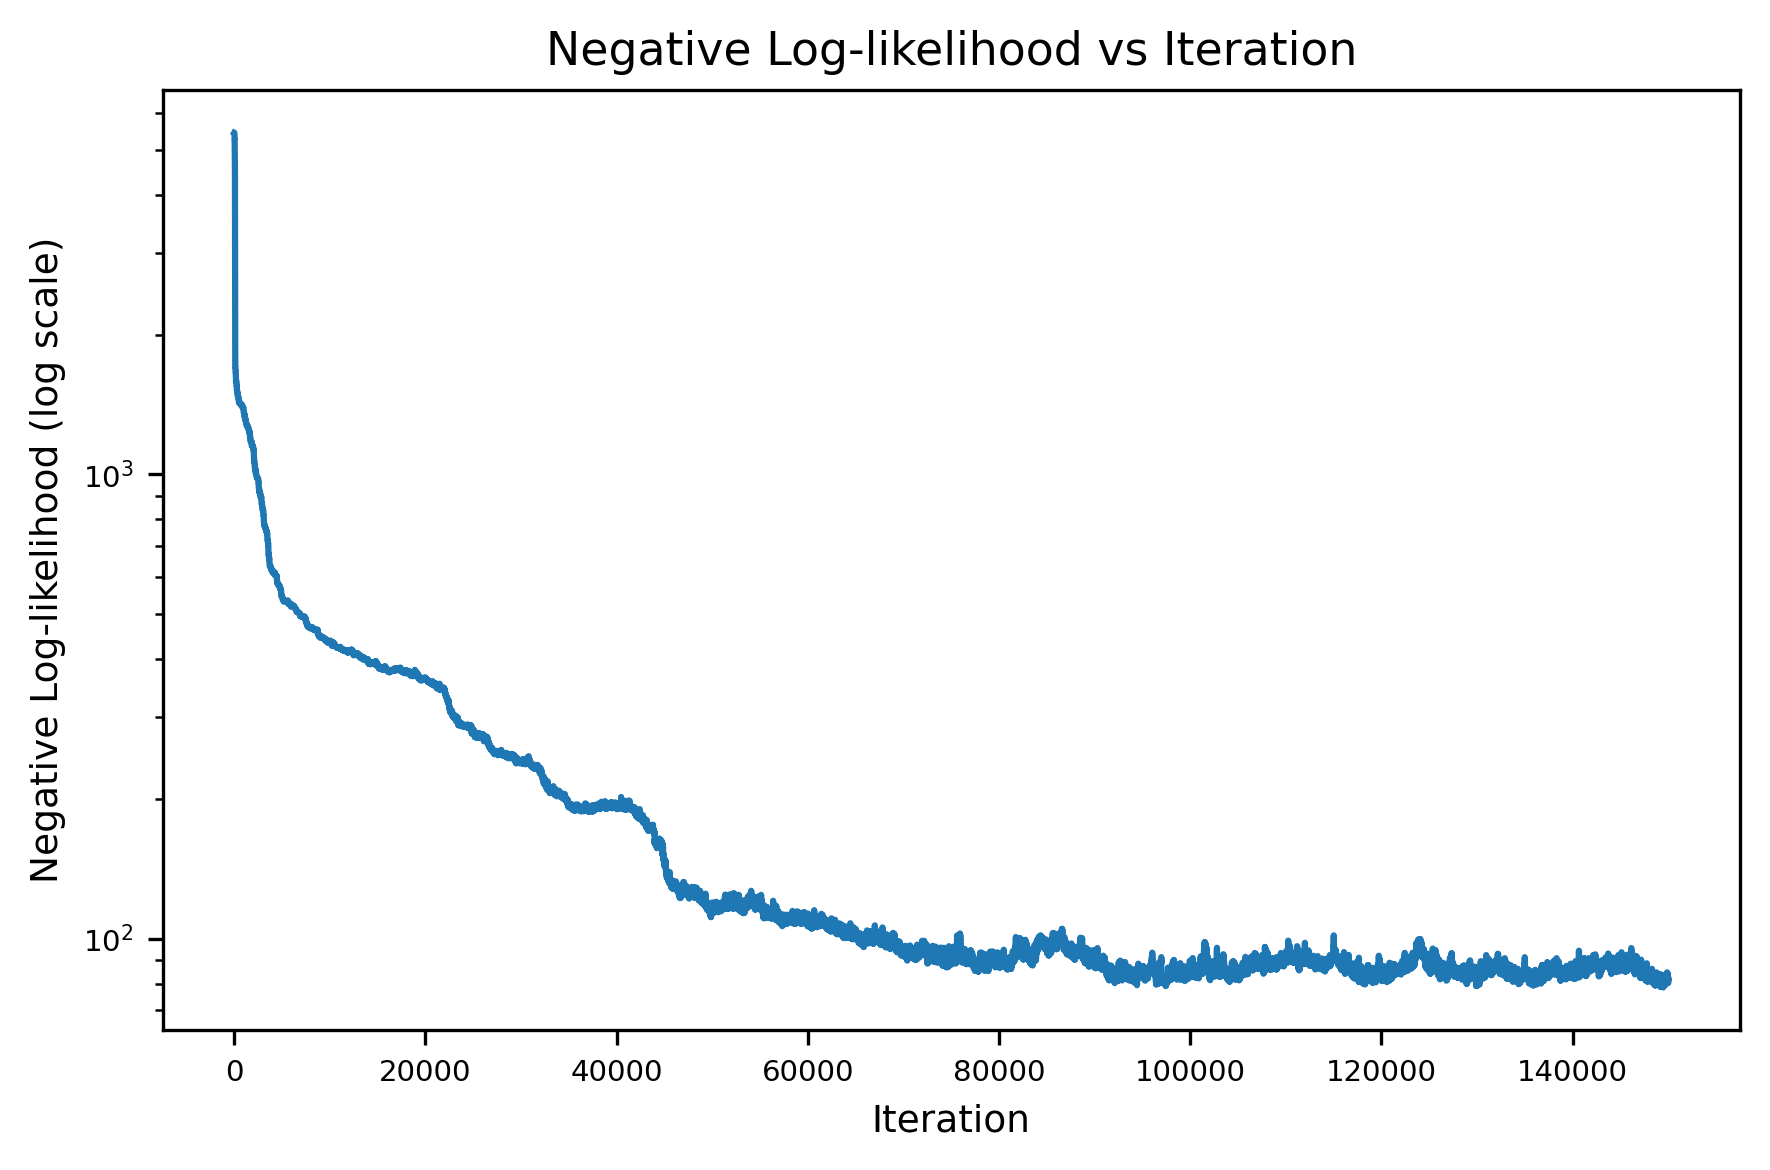

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
ax.plot(-np.array(loss_evolution))
ax.set_yscale('log')
ax.set_title("Negative Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("Negative Log-likelihood (log scale)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

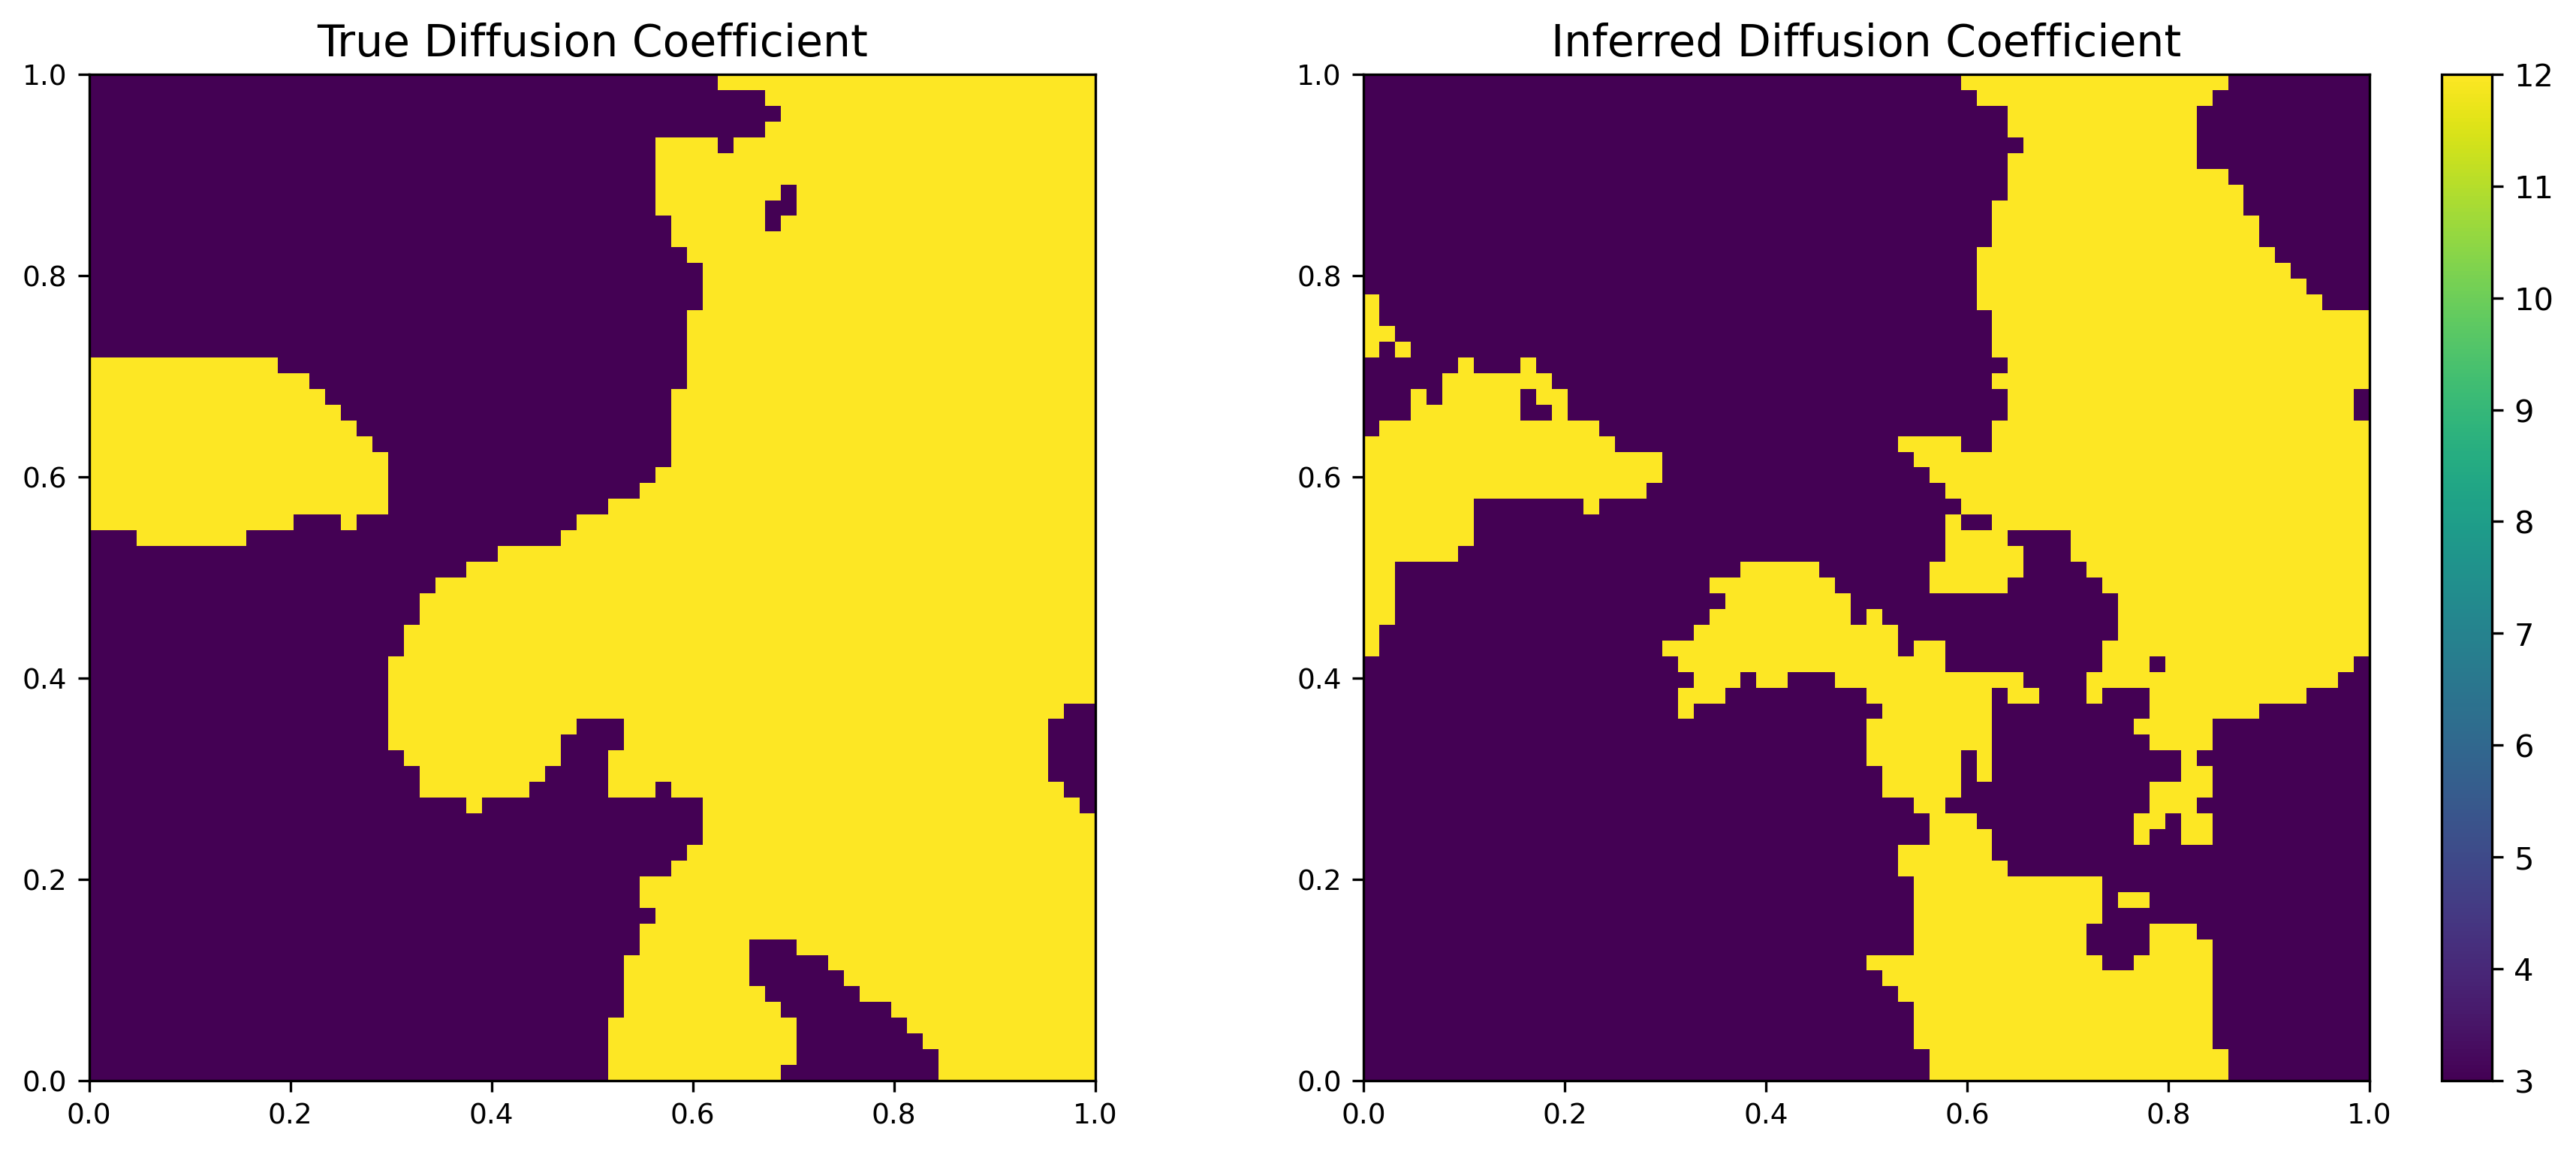

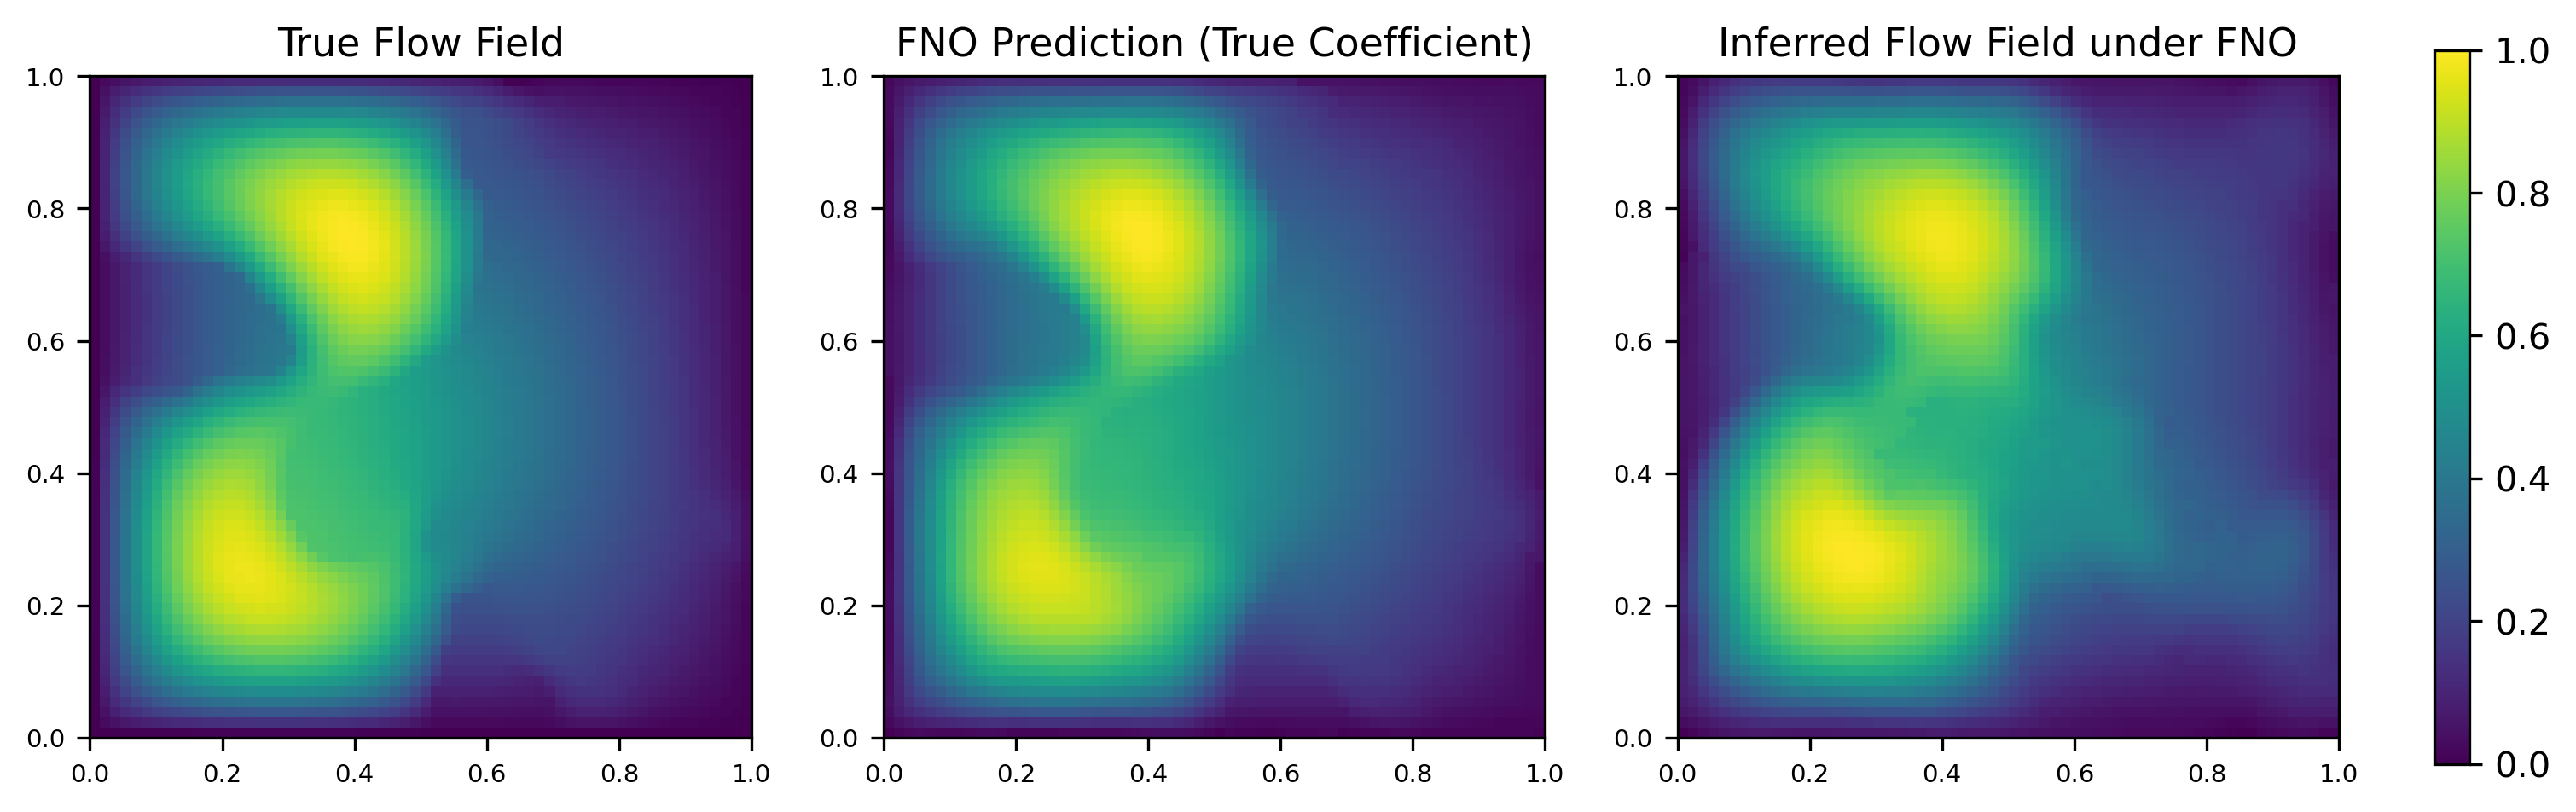

In [ ]:
with torch.no_grad():
    forwards = predict(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

average_predicted_field = T_push(torch.from_numpy(np.mean(theta_evolution[-1:], axis=0)), tau=-1, boundary=7.5).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    predicted_solution = predict(average_predicted_field.to(device)).cpu().numpy()[0, 0]

average_predicted_field = average_predicted_field.squeeze(0).squeeze(0)
fno_prediction = forwards.cpu().numpy()[0, 0]

fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)
fields1 = [true_field.cpu().numpy()[0, 0], average_predicted_field]
titles1 = ["True Diffusion Coefficient", "Inferred Diffusion Coefficient"]
for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, extent=[0, 1, 0, 1], origin='lower')
    ax.set_title(title, fontsize=14, loc='center', pad=6)
    ax.tick_params(labelsize=9)
fig1.colorbar(im, ax=axs1, fraction=0.03, pad=0.02, shrink=1.0, aspect=20)
plt.show()

fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
fields2 = [true_observations.cpu().numpy()[0, 0], fno_prediction, predicted_solution]
titles2 = ["True Flow Field", "FNO Prediction (True Coefficient)", "Inferred Flow Field under FNO"]
for ax, field, title in zip(axs2, fields2, titles2):
    field_norm = (field - field.min()) / (field.max() - field.min())
    im = ax.imshow(field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.tick_params(labelsize=7)
fig2.colorbar(im, ax=axs2, fraction=0.015, pad=0.04)
plt.show()

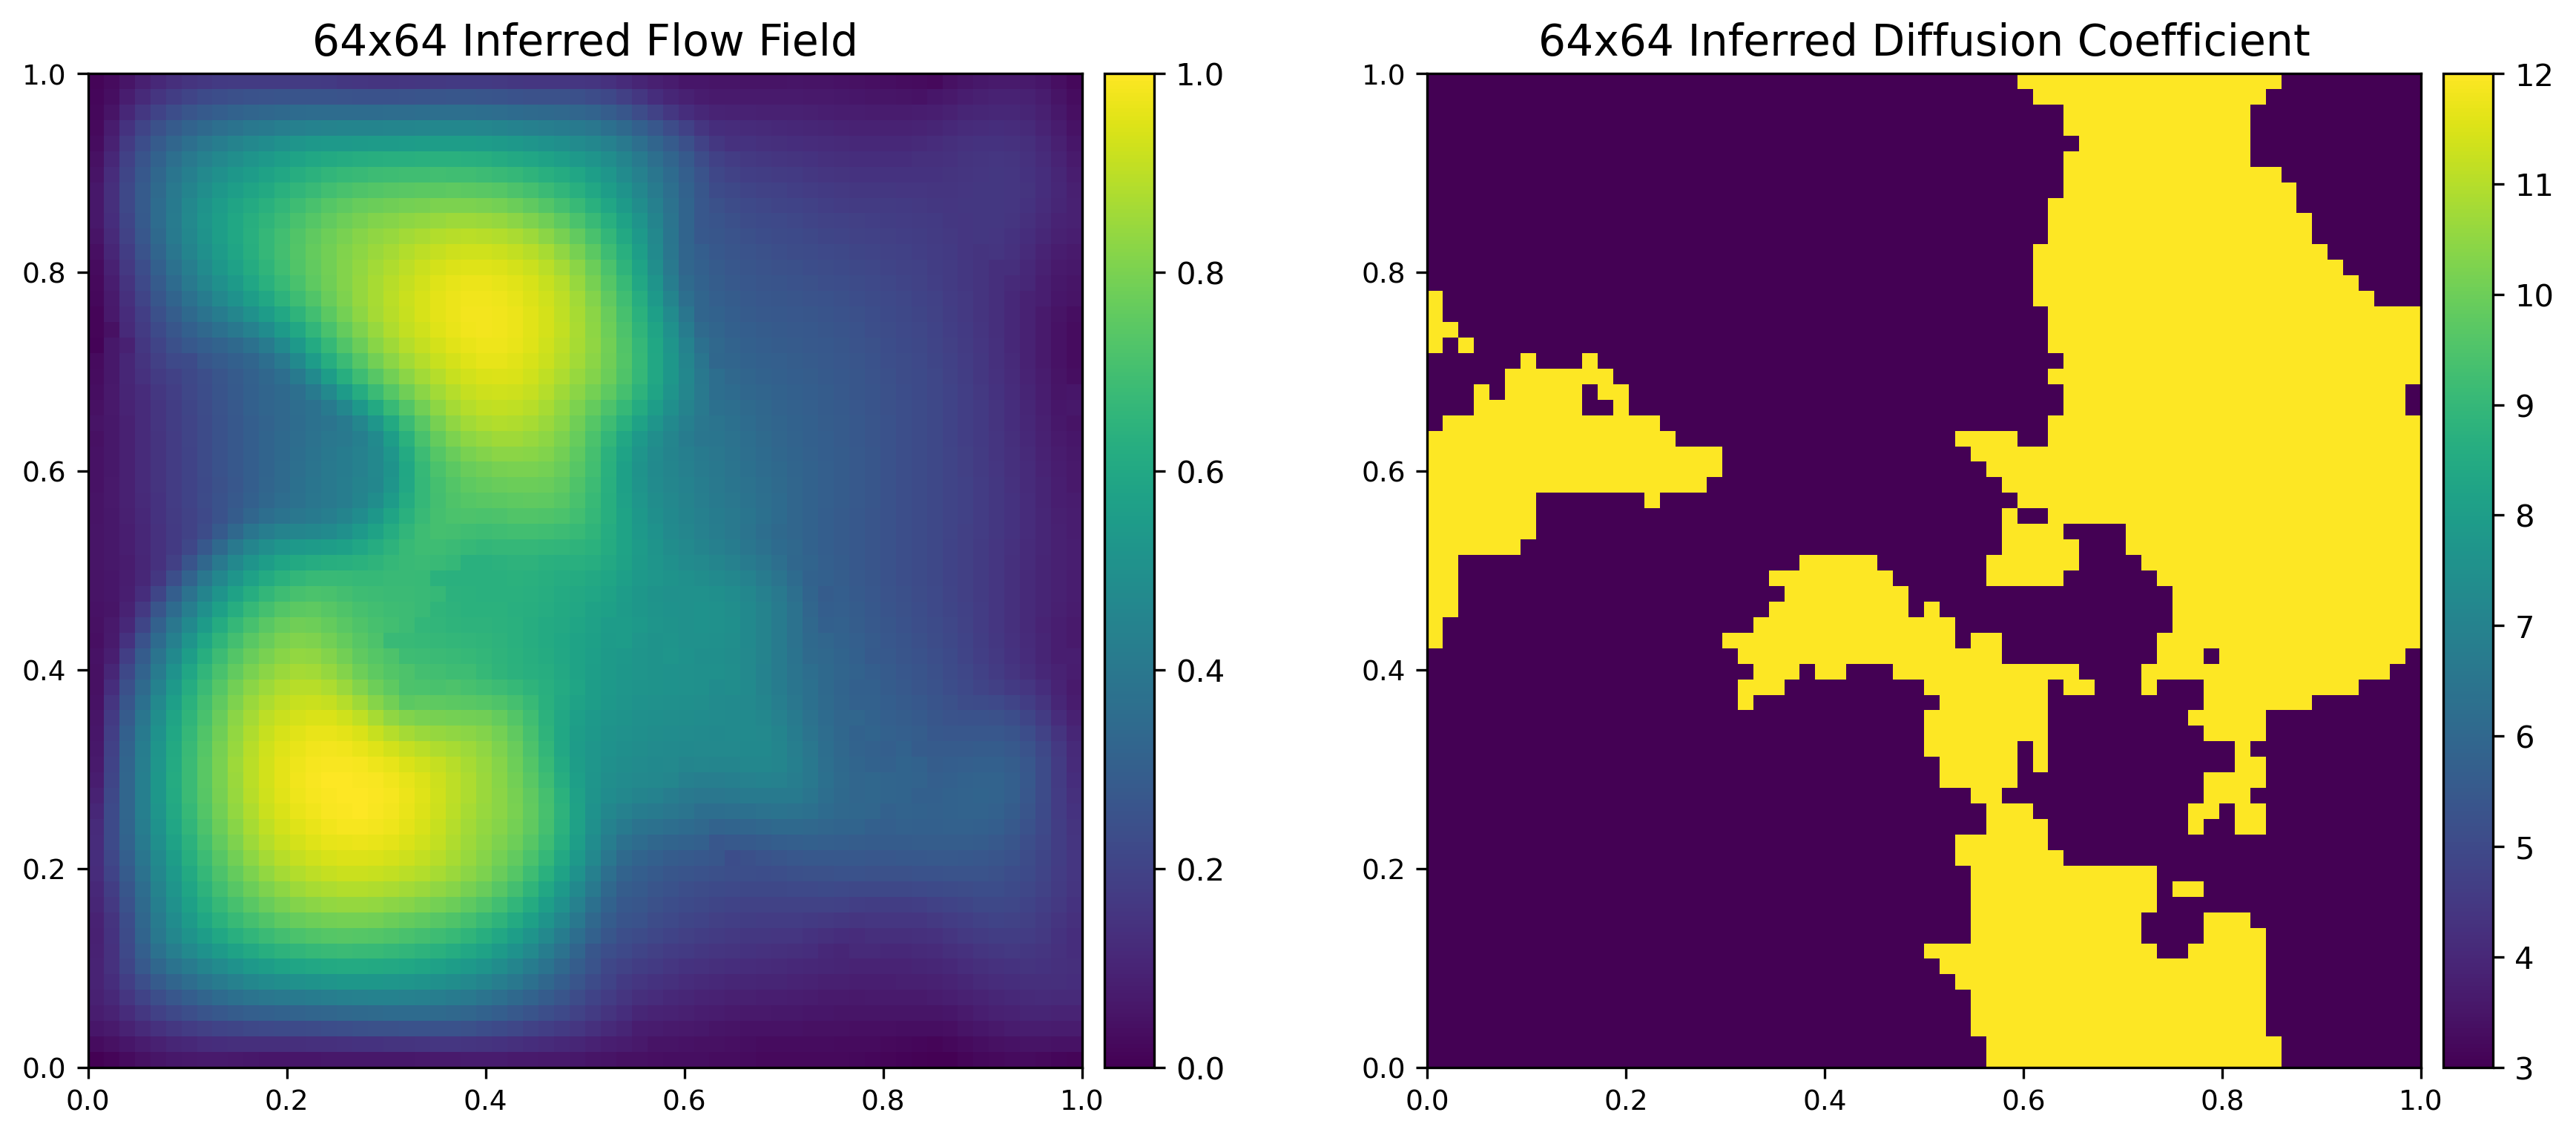

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)

flow_field = predicted_solution
flow_field_norm = (flow_field - flow_field.min()) / (flow_field.max() - flow_field.min())
im0 = axs[0].imshow(flow_field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
axs[0].set_title("64x64 Inferred Flow Field", fontsize=14, loc='center', pad=6)
axs[0].tick_params(labelsize=9)
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im0, cax=cax0)

diff_field = average_predicted_field
im1 = axs[1].imshow(diff_field, extent=[0, 1, 0, 1], origin='lower')
axs[1].set_title("64x64 Inferred Diffusion Coefficient", fontsize=14, loc='center', pad=6)
axs[1].tick_params(labelsize=9)
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im1, cax=cax1)

# plt.savefig('figures_for_report/super_res_combined_inferred.png', bbox_inches='tight', dpi=300)
plt.show()

In [46]:
# FNO error on the true coefficient
true_field = dataset.test_dbs[64].x[0, 0].unsqueeze(0).unsqueeze(0)
theta_true_tensor = torch.tensor(true_field.cpu().numpy()[0, 0], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_true = log_likelihood(theta_true_tensor, true_observations, model, sigma=sigma)
print(f"NLL with true coefficient: {ll_true:.2f}")
print(f"NLL of MCMC solution:      {ll_current:.2f}")

NLL with true coefficient: -10.95
NLL of MCMC solution:      -82.24


In [73]:
# Losses
pred = torch.tensor(predicted_solution).unsqueeze(0).unsqueeze(0)
pred_norm = (pred - pred.min()) / (pred.max() - pred.min())
obs = true_observations.cpu()[0, 0]
obs_norm = (obs - obs.min()) / (obs.max() - obs.min())
obs_norm = obs_norm.unsqueeze(0).unsqueeze(0)

h1_pred = h1loss(pred_norm, obs_norm)
l2_pred = l2loss(pred_norm, obs_norm)
print(f"H1 Loss of MCMC solution: {h1_pred.item():.4f}")
print(f"L2 Loss of MCMC solution: {l2_pred.item():.4f}")

with torch.no_grad():
    FNO_predicted_true = predict(theta_true_tensor).cpu()[0, 0]

fno_norm = (FNO_predicted_true - FNO_predicted_true.min()) / (FNO_predicted_true.max() - FNO_predicted_true.min())
fno_norm = fno_norm.unsqueeze(0).unsqueeze(0)

h1_true = h1loss(fno_norm, obs_norm)
l2_true = l2loss(fno_norm, obs_norm)
print(f"H1 Loss of true solution: {h1_true.item():.4f}")
print(f"L2 Loss of true solution: {l2_true.item():.4f}")

H1 Loss of MCMC solution: 0.3560
L2 Loss of MCMC solution: 0.1087
H1 Loss of true solution: 2.1216
L2 Loss of true solution: 1.1503


In [ ]:
# At the end of training, check PDE residual on a test instance
model.eval()
with torch.no_grad():
    a_test = dataset.test_dbs[64].x[0,0].unsqueeze(0).unsqueeze(0).to(device)
    u_test = dataset.test_dbs[64].y[0,0].unsqueeze(0).unsqueeze(0).to(device)
    u_pred = predict(a_test)
    pde_res = darcy_pde_residual(a_test, u_pred)
    print("PDE residual on test instance:", pde_res.item())
    print("PDE residual on true solution:", darcy_pde_residual(a_test, u_test).item())

PDE residual on test instance: 30574.052734375
PDE residual on true solution: 24311.57421875


In [ ]:
# Estimate a reasonable sigma from the FNO's own error on the true field
with torch.no_grad():
    fno_pred = predict(theta_true_tensor)
    residuals = (true_observations - fno_pred[0,0])
    print(f"Suggested sigma: {residuals.std().item():.4f}")

Suggested sigma: 0.0156


Text(0.5, 1.0, 'Mean absolute change per step')

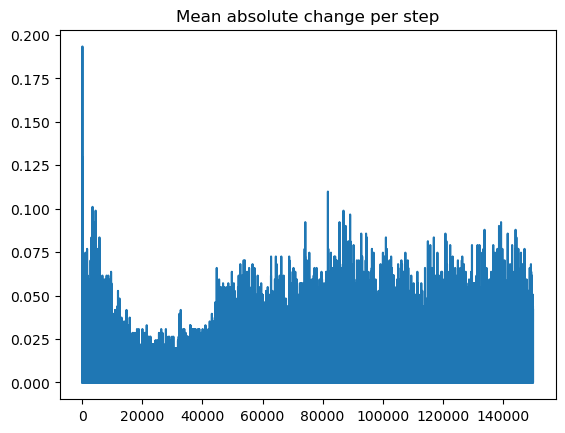

In [74]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1]))
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")

In [75]:
with torch.no_grad():
    print(darcy_pde_residual(a_test, u_test).item())  # should be << 1
    print(darcy_pde_residual(a_test, u_pred).item())  # model prediction

84678.4609375
63991.671875


In [71]:
with torch.no_grad():
    B, C, Nx, Ny = u_test.shape
    u = u_test.squeeze(1)
    a = a_test.squeeze(1)
    dx = 1.0 / (Nx - 1)
    
    ux  = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) / (2*dx)
    uxx = (u[:, 2:, 1:-1] - 2*u[:, 1:-1, 1:-1] + u[:, :-2, 1:-1]) / dx**2
    ax  = (a[:, 2:, 1:-1] - a[:, :-2, 1:-1]) / (2*dx)
    a_int = a[:, 1:-1, 1:-1]
    
    print("u range:",    u.min().item(),    u.max().item())
    print("ux range:",   ux.min().item(),   ux.max().item())
    print("uxx range:",  uxx.min().item(),  uxx.max().item())
    print("ax range:",   ax.min().item(),   ax.max().item())
    print("a_int range:", a_int.min().item(), a_int.max().item())
    print("dx:", dx)

u range: 0.00016143391258083284 0.9413905739784241
ux range: -7.237543106079102 7.7985920906066895
uxx range: -143.16261291503906 431.10552978515625
ax range: -283.5 283.5
a_int range: 3.0 12.0
dx: 0.015873015873015872


In [76]:
def recover_forcing(a, u):
    a = a.squeeze(1); u = u.squeeze(1)
    dx = 1.0 / (u.shape[-1] - 1)
    axp = 2*a[:,1:,:]*a[:,:-1,:]/(a[:,1:,:]+a[:,:-1,:])
    ayp = 2*a[:,:,1:]*a[:,:,:-1]/(a[:,:,1:]+a[:,:,:-1])
    Fx = axp*(u[:,1:,:]-u[:,:-1,:])/dx
    Fy = ayp*(u[:,:,1:]-u[:,:,:-1])/dx
    div = (Fx[:,1:,:]-Fx[:,:-1,:])/dx
    div = div[:,:,1:-1] + ((Fy[:,:,1:]-Fy[:,:,:-1])/dx)[:,1:-1,:]
    f_field = -div
    print("recovered f:  mean=%.3f  std=%.3f  median=%.3f" %
          (f_field.mean(), f_field.std(), f_field.median()))

with torch.no_grad():
    recover_forcing(a_test, u_test)

recovered f:  mean=61.766  std=188.041  median=35.361
